In [12]:
# Import libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

print("Libraries loaded!")

Libraries loaded!


## Step 1 - Load the Dataset

In [13]:
# Load the dataset
df = pd.read_csv('../data/weddify_dataset_v_final.csv')

# Check basic info
print("Number of rows    :", df.shape[0])
print("Number of columns :", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())

Number of rows    : 13304
Number of columns : 14

Column names:
['vendor_name', 'Category', 'Location', 'Price Tier', 'Price (LKR)', 'Rating (out of 5)', 'Experience (Years)', 'Weddings Completed', 'Response Time (Hours)', 'Verified', 'Number of Packages', 'Social Media Followers', 'Repeat Client Rate', 'Recommended']


In [14]:
# See first 5 rows
df.head()

,vendor_name,Category,Location,Price Tier,Price (LKR),Rating (out of 5),Experience (Years),Weddings Completed,Response Time (Hours),Verified,Number of Packages,Social Media Followers,Repeat Client Rate,Recommended
0,Artisan Cards Lanka,Wedding Invitations,Colombo,Mid-Range,36000,3.8,8,120,3.0,Yes,2,37492,0.35,Yes
1,Suwandha Catering,Catering,Colombo,Premium,1051800,5.0,13,182,5.4,Yes,6,100000,0.60,Yes
2,Sithara Bridal Studio,Attire & Beauty,Colombo,Mid-Range,92500,4.0,12,300,13.1,No,3,12616,0.44,Yes
3,Luxury Rides Lanka,Wedding Cars,Colombo,Mid-Range,59300,4.7,17,221,1.8,Yes,2,28867,0.45,Yes
4,Paper & Petals Lanka,Wedding Invitations,Kurunegala,Mid-Range,33300,3.8,7,63,11.2,No,4,18873,0.32,No


## Step 2 - Check Data Quality

In [15]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

Missing values in each column:
vendor_name               0
Category                  0
Location                  0
Price Tier                0
Price (LKR)               0
Rating (out of 5)         0
Experience (Years)        0
Weddings Completed        0
Response Time (Hours)     0
Verified                  0
Number of Packages        0
Social Media Followers    0
Repeat Client Rate        0
Recommended               0
dtype: int64

Duplicate rows: 0


## Step 3 - Check Target Column (Recommended)
This is what our model will predict - Yes or No

Recommended
No     6672
Yes    6632
Name: count, dtype: int64


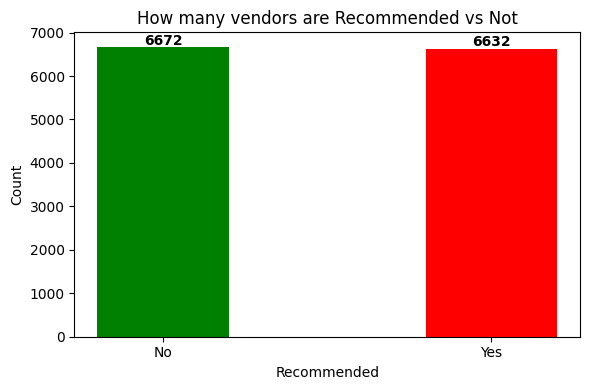

In [16]:
# Count Yes and No
counts = df['Recommended'].value_counts()
print(counts)

# Plot it
plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values, color=['green', 'red'], width=0.4)
plt.title('How many vendors are Recommended vs Not')
plt.xlabel('Recommended')
plt.ylabel('Count')
for i, v in enumerate(counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/eda_class_balance.png')
plt.show()

## Step 4 - Check Each Category
How many vendors are in each wedding service category?

Category
Entertainment          1630
Decorators             1569
Photographers          1501
Catering               1500
Wedding Cakes          1474
Venues                 1469
Wedding Cars           1457
Attire & Beauty        1362
Wedding Invitations    1342
Name: count, dtype: int64


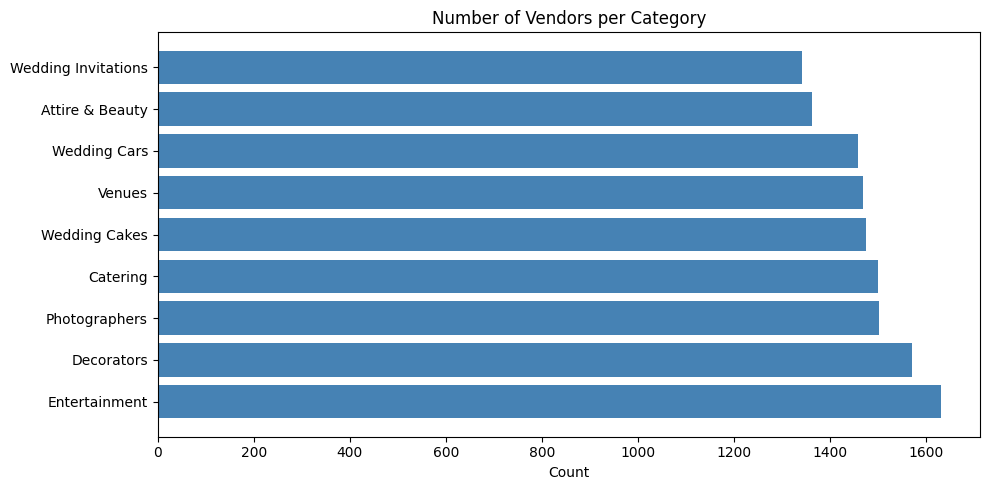

In [17]:
# Count vendors per category
cat_counts = df['Category'].value_counts()
print(cat_counts)

# Plot it
plt.figure(figsize=(10, 5))
plt.barh(cat_counts.index, cat_counts.values, color='steelblue')
plt.title('Number of Vendors per Category')
plt.xlabel('Count')
plt.tight_layout()
plt.savefig('../outputs/figures/eda_category_distribution.png')
plt.show()

## Step 5 - Check Price Distribution
How much do vendors charge on average?

Category
Wedding Invitations     39619.0
Wedding Cars            45974.0
Wedding Cakes           58361.0
Attire & Beauty        112135.0
Entertainment          122568.0
Photographers          127479.0
Decorators             217949.0
Catering               348882.0
Venues                 417903.0
Name: Price (LKR), dtype: float64


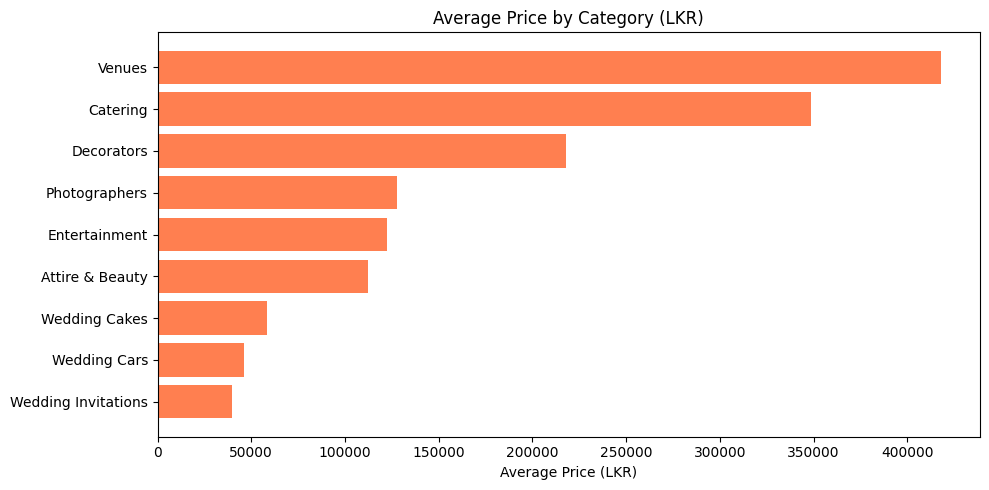

In [18]:
# Average price per category
avg_price = df.groupby('Category')['Price (LKR)'].mean().sort_values()
print(avg_price.round(0))

# Plot it
plt.figure(figsize=(10, 5))
plt.barh(avg_price.index, avg_price.values, color='coral')
plt.title('Average Price by Category (LKR)')
plt.xlabel('Average Price (LKR)')
plt.tight_layout()
plt.savefig('../outputs/figures/eda_price_by_category.png')
plt.show()

## Step 6 - Check Rating Distribution
What ratings do vendors usually get?

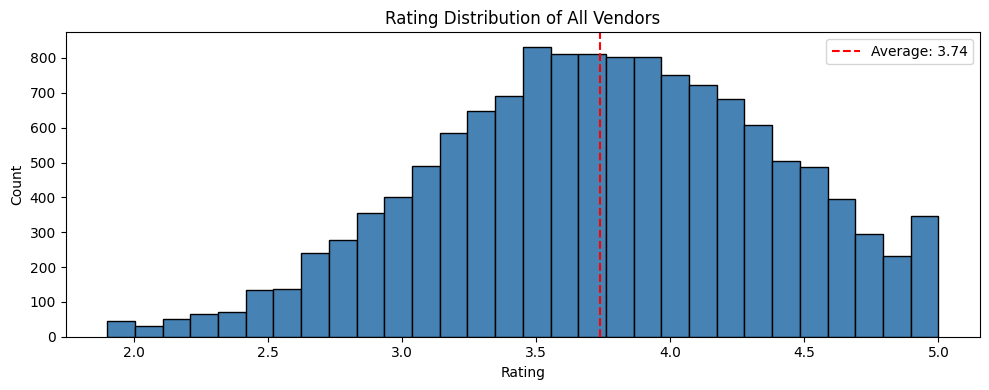

Average rating of Recommended vendors    : 4.06
Average rating of Not Recommended vendors: 3.42


In [19]:
# Overall rating distribution
plt.figure(figsize=(10, 4))
plt.hist(df['Rating (out of 5)'], bins=30, color='steelblue', edgecolor='black')
plt.axvline(df['Rating (out of 5)'].mean(), color='red', linestyle='--',
            label=f"Average: {df['Rating (out of 5)'].mean():.2f}")
plt.title('Rating Distribution of All Vendors')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/eda_rating_distribution.png')
plt.show()

# Compare ratings - recommended vs not
print("Average rating of Recommended vendors    :", 
      df[df['Recommended']=='Yes']['Rating (out of 5)'].mean().round(2))
print("Average rating of Not Recommended vendors:", 
      df[df['Recommended']=='No']['Rating (out of 5)'].mean().round(2))

## Step 7 - Check Location Distribution
Which districts have the most vendors?

Location
Colombo         2246
Gampaha         1720
Kandy           1040
Galle           1036
Kalutara         913
Negombo          578
Kurunegala       545
Jaffna           535
Matara           498
Hambantota       443
Badulla          390
Ratnapura        359
Kegalle          353
Anuradhapura     351
Batticaloa       341
Matale           306
Trincomalee      303
Nuwara Eliya     255
Puttalam         240
Monaragala       189
Mannar           175
Polonnaruwa      137
Mullaitivu       130
Ampara           114
Vavuniya         107
Name: count, dtype: int64


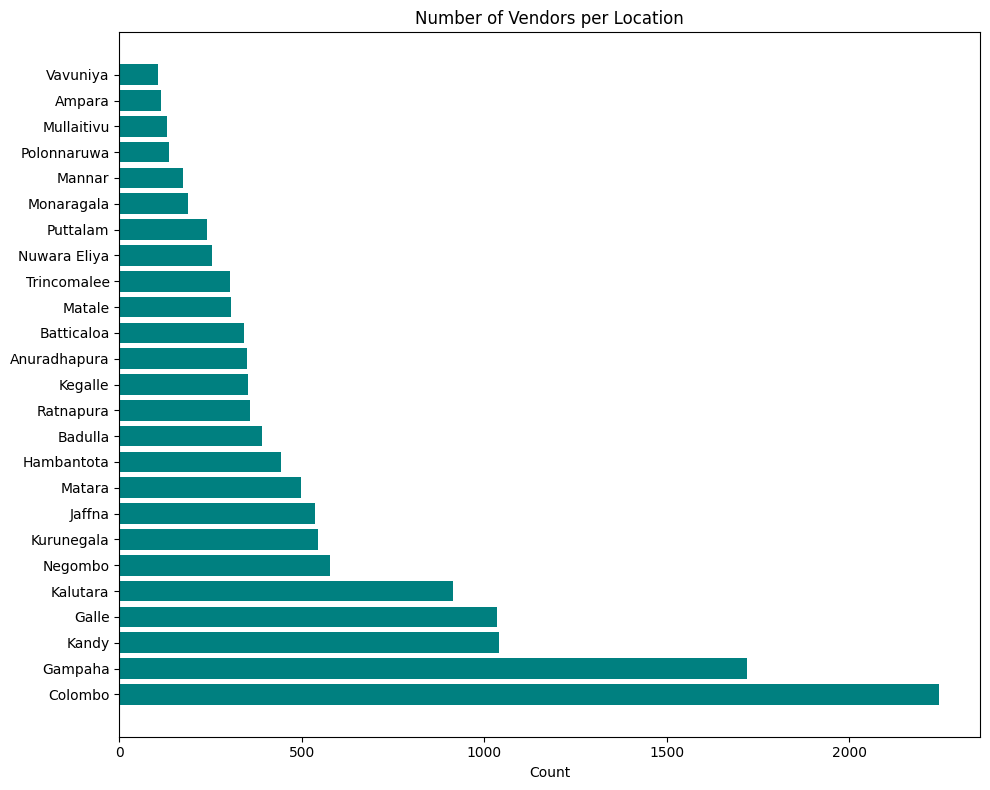

In [20]:
# Count vendors per location
loc_counts = df['Location'].value_counts()
print(loc_counts)

# Plot it
plt.figure(figsize=(10, 8))
plt.barh(loc_counts.index, loc_counts.values, color='teal')
plt.title('Number of Vendors per Location')
plt.xlabel('Count')
plt.tight_layout()
plt.savefig('../outputs/figures/eda_location_distribution.png')
plt.show()

## Step 8 - Correlation Heatmap
Which features are most related to Recommended?

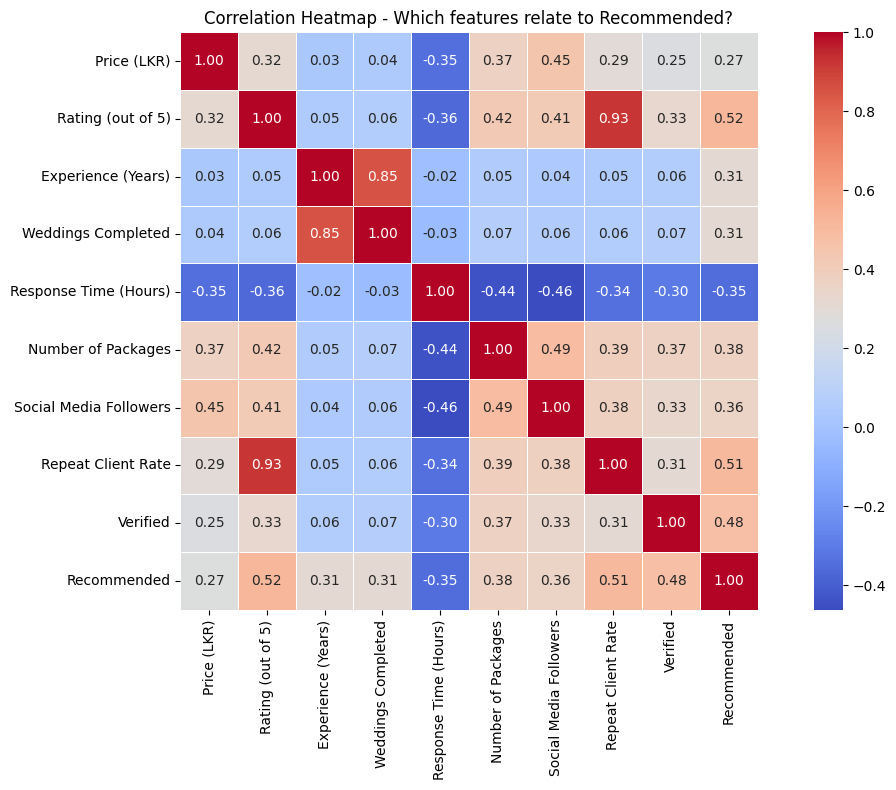

In [21]:
# Convert text columns to numbers for correlation
df_corr = df.copy()
df_corr['Recommended'] = (df_corr['Recommended'] == 'Yes').astype(int)
df_corr['Verified']    = (df_corr['Verified'] == 'Yes').astype(int)

# Select only number columns
num_cols = ['Price (LKR)', 'Rating (out of 5)', 'Experience (Years)',
            'Weddings Completed', 'Response Time (Hours)',
            'Number of Packages', 'Social Media Followers',
            'Repeat Client Rate', 'Verified', 'Recommended']

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_corr[num_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Heatmap - Which features relate to Recommended?')
plt.tight_layout()
plt.savefig('../outputs/figures/eda_correlation_heatmap.png')
plt.show()

## Step 9 - Price Tier vs Recommended
Do premium vendors get recommended more?

Recommended    No   Yes
Price Tier             
Budget       4143  1188
Mid-Range    2230  3148
Premium       299  2296


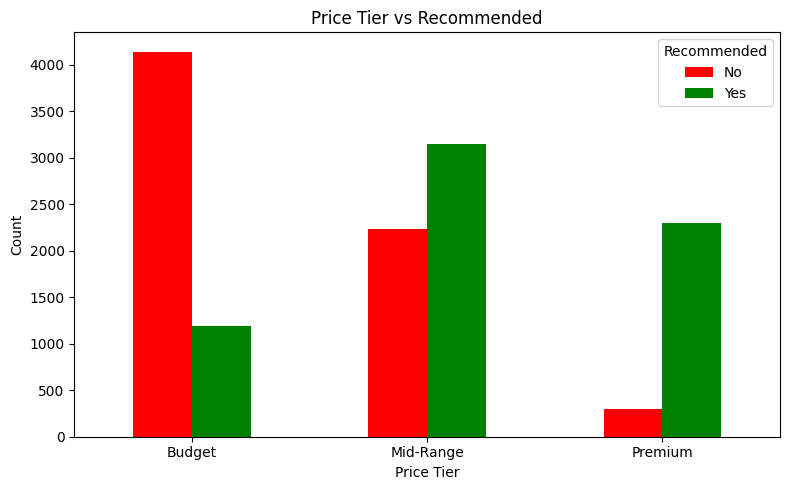

In [22]:
# Group by tier and recommended
tier_rec = df.groupby(['Price Tier', 'Recommended']).size().unstack()
tier_rec = tier_rec.reindex(['Budget', 'Mid-Range', 'Premium'])
print(tier_rec)

# Plot it
tier_rec.plot(kind='bar', color=['red', 'green'], figsize=(8, 5), rot=0)
plt.title('Price Tier vs Recommended')
plt.xlabel('Price Tier')
plt.ylabel('Count')
plt.legend(title='Recommended')
plt.tight_layout()
plt.savefig('../outputs/figures/eda_tier_vs_recommended.png')
plt.show()